# Owner Earnings（所有者盈余）估值教程

本教程将带你深入了解 **Owner Earnings** —— 沃伦·巴菲特最看重的盈利质量指标。

## 学习目标

1. 理解 Owner Earnings 的概念和巴菲特的原始定义
2. 掌握公式中每个组成部分的经济含义
3. 区分「净利润」和「所有者盈余」的差异
4. 使用 `valueinvest` 库获取真实数据并估值
5. 手动计算每一步，理解盈利质量评估
6. 多公司对比，识别盈利质量差异

---

> 本教程使用 [ValueInvest](https://github.com/wangzhe3224/valueinvest) 库

## 1. 什么是 Owner Earnings？

### 巴菲特的原始定义（1986 年致股东信）

> "If we think through these questions, we can gain some insights about what may be called 'owner earnings.' These represent (a) reported earnings plus (b) depreciation, depletion, amortization, and certain other non-cash charges... less (c) the average annual amount of capitalized expenditures for plant and equipment, etc. that the business requires to fully maintain its long-term competitive position and its unit volume."

翻译：**所有者盈余** = 报告利润 + 非现金费用 - 维持竞争力的资本支出 - 营运资金变动

### 核心公式

$$\text{Owner Earnings} = \text{Net Income} + \text{D\&A} - \text{Maintenance CapEx} - \Delta\text{NWC}$$

| 组成部分 | 含义 |
|----------|------|
| **Net Income** | 报告净利润（起点） |
| **+ Depreciation & Amortization** | 加回非现金折旧摊销 |
| **- Maintenance CapEx** | 减去维持竞争力所需资本支出 |
| **- Change in NWC** | 减去营运资金变动 |

### 为什么净利润不够？

净利润（Net Income）的问题：
1. **包含非现金收入** — 可能有大量应收账款未回收
2. **未扣除维持性资本支出** — 公司必须持续投入才能保持竞争力
3. **忽略营运资金变化** — 库存和应收账款的增加消耗了现金

Owner Earnings 回答的问题是：**公司真正能放进股东口袋里的钱是多少？**

### 盈利质量指标

$$\text{Earnings Quality} = \frac{\text{Owner Earnings}}{\text{Net Income}}$$

| 比值 | 含义 |
|------|------|
| > 1.2 | **Cash-rich** — 实际现金流远超报告利润 |
| 0.8 - 1.2 | **Normal** — 利润与现金基本匹配 |
| < 0.8 | **Accrual-heavy** — 报告利润含水量高 |

In [1]:
# 导入必要的库
import sys
sys.path.insert(0, '..')

from valueinvest import Stock, ValuationEngine
from valueinvest.valuation.quality import OwnerEarnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("库加载成功")

库加载成功


## 2. 获取真实股票数据

Owner Earnings 需要以下数据：
- **Net Income**（净利润）
- **Depreciation & Amortization**（折旧摊销）
- **CapEx**（资本支出）
- **Net Working Capital**（净营运资金）
- **Shares Outstanding**（流通股数）
- **Cost of Capital**（资本成本）
- **Current Price**（当前股价）

我们选择 **Apple (AAPL)** 作为示例——巴菲特的重仓股，也是盈利质量分析的典型案例。

In [2]:
# 获取 Apple 数据
ticker = "AAPL"
print(f"正在获取 {ticker} 数据...\n")

stock = Stock.from_api(ticker)

print("=" * 60)
print(f"公司：{stock.name} ({stock.ticker})")
print("=" * 60)
print(f"当前股价：${stock.current_price:.2f}")
print(f"\n--- Owner Earnings 所需数据 ---")
print(f"  净利润 (Net Income)：${stock.net_income/1e9:.2f}B")
print(f"  折旧摊销 (D&A)：${stock.depreciation/1e9:.2f}B")
print(f"  资本支出 (CapEx)：${stock.capex/1e9:.2f}B")
print(f"  净营运资金 (NWC)：${stock.net_working_capital/1e9:.2f}B")
print(f"  流通股数：{stock.shares_outstanding/1e9:.2f}B")
print(f"  资本成本：{stock.cost_of_capital:.2f}%")
print(f"  增长率：{stock.growth_rate:.1f}%")
print(f"  营收：${stock.revenue/1e9:.2f}B")

正在获取 AAPL 数据...

公司：Apple Inc. (AAPL)
当前股价：$246.63

--- Owner Earnings 所需数据 ---
  净利润 (Net Income)：$112.01B
  折旧摊销 (D&A)：$11.70B
  资本支出 (CapEx)：$12.71B
  净营运资金 (NWC)：$-17.67B
  流通股数：14.68B
  资本成本：10.00%
  增长率：15.7%
  营收：$416.16B


## 3. 理解公式中每个组成

让我们深入理解 Owner Earnings 公式的每个部分。

In [3]:
print("Owner Earnings 公式拆解")
print("=" * 60)
print(f"公司：{stock.name} ({stock.ticker})")
print("=" * 60)

# (a) Net Income — 起点
net_income = stock.net_income
print(f"\n(a) Net Income (净利润)")
print(f"    金额：${net_income/1e9:.2f}B")
print(f"    这是利润表上的'底线数字'")
print(f"    问题：包含非现金项目和未扣除维持性支出")

# (b) Depreciation & Amortization — 加回非现金费用
dep = stock.depreciation
print(f"\n(b) + Depreciation & Amortization (折旧摊销)")
print(f"    金额：${dep/1e9:.2f}B")
print(f"    原因：这是会计上的费用，但并没有实际现金流出")
print(f"    加回后：${(net_income + dep)/1e9:.2f}B")

# (c) Maintenance CapEx — 减去维持性资本支出
total_capex = abs(stock.capex)
maintenance_pct = 0.7  # 假设 70% 的 CapEx 是维持性的
maintenance_capex = total_capex * maintenance_pct
print(f"\n(c) - Maintenance CapEx (维持性资本支出)")
print(f"    总 CapEx：${total_capex/1e9:.2f}B")
print(f"    维持性占比：{maintenance_pct:.0%}")
print(f"    维持性 CapEx：${maintenance_capex/1e9:.2f}B")
print(f"    原因：公司必须持续投入才能保持竞争力")
print(f"    关键区分：维持性 vs 增长性 CapEx")
after_capex = net_income + dep - maintenance_capex
print(f"    减去后：${after_capex/1e9:.2f}B")

# (d) Change in NWC — 减去营运资金变动
nwc = stock.net_working_capital
nwc_change = abs(nwc) * 0.1  # 简化估计
print(f"\n(d) - Change in Net Working Capital (营运资金变动)")
print(f"    净营运资金：${nwc/1e9:.2f}B")
print(f"    估计变动额：${nwc_change/1e9:.2f}B")
print(f"    原因：库存和应收账款增加意味着现金被占用")

# 最终结果
owner_earnings_manual = net_income + dep - maintenance_capex - nwc_change
print(f"\n{'=' * 60}")
print(f"Owner Earnings = {net_income/1e9:.2f}B + {dep/1e9:.2f}B - {maintenance_capex/1e9:.2f}B - {nwc_change/1e9:.2f}B")
print(f"             = ${owner_earnings_manual/1e9:.2f}B")
print(f"\nvs. Net Income = ${net_income/1e9:.2f}B")
eq_ratio = owner_earnings_manual / net_income
eq_label = "Cash-rich" if eq_ratio > 1.2 else ("Accrual-heavy" if eq_ratio < 0.8 else "Normal")
print(f"Earnings Quality = {eq_ratio:.1%} ({eq_label})")

Owner Earnings 公式拆解
公司：Apple Inc. (AAPL)

(a) Net Income (净利润)
    金额：$112.01B
    这是利润表上的'底线数字'
    问题：包含非现金项目和未扣除维持性支出

(b) + Depreciation & Amortization (折旧摊销)
    金额：$11.70B
    原因：这是会计上的费用，但并没有实际现金流出
    加回后：$123.71B

(c) - Maintenance CapEx (维持性资本支出)
    总 CapEx：$12.71B
    维持性占比：70%
    维持性 CapEx：$8.90B
    原因：公司必须持续投入才能保持竞争力
    关键区分：维持性 vs 增长性 CapEx
    减去后：$114.81B

(d) - Change in Net Working Capital (营运资金变动)
    净营运资金：$-17.67B
    估计变动额：$1.77B
    原因：库存和应收账款增加意味着现金被占用

Owner Earnings = 112.01B + 11.70B - 8.90B - 1.77B
             = $113.04B

vs. Net Income = $112.01B
Earnings Quality = 100.9% (Normal)


## 4. 使用 valueinvest 库运行估值

In [4]:
# 使用 ValuationEngine 运行 Owner Earnings
engine = ValuationEngine()
result = engine.run_single(stock, "owner_earnings")

print("=" * 60)
print(f"Owner Earnings 估值结果：{stock.name} ({stock.ticker})")
print("=" * 60)

if result.fair_value and result.fair_value > 0:
    print(f"\n估值结果")
    print(f"   合理价值：${result.fair_value:.2f}")
    print(f"   当前股价：${result.current_price:.2f}")
    print(f"   溢价/折价：{result.premium_discount:+.1f}%")
    print(f"   评估：{result.assessment}")
    
    if result.fair_value_range:
        print(f"\n估值区间")
        print(f"   保守：${result.fair_value_range.low:.2f}")
        print(f"   基准：${result.fair_value_range.base:.2f}")
        print(f"   乐观：${result.fair_value_range.high:.2f}")
    
    print(f"\n详细信息")
    d = result.details
    print(f"   Owner Earnings：${d['owner_earnings']/1e9:.2f}B")
    print(f"   Owner Earnings/Share：${d['owner_earnings_per_share']:.2f}")
    print(f"   盈利质量：{d['earnings_quality']:.1%}")
    print(f"   隐含 P/E (OE)：{d['implied_pe']:.1f}x")
    print(f"   零增长价值：${d['zero_growth_value']:.2f}")
    print(f"   含增长价值：${d['growth_value']:.2f}")
    
    print(f"\n计算组成")
    c = result.components
    print(f"   净利润：${c['net_income']/1e9:.2f}B")
    print(f"   折旧摊销：${c['depreciation']/1e9:.2f}B")
    print(f"   维持性CapEx：${c['maintenance_capex']/1e9:.2f}B")
    print(f"   营运资金变动：${c['nwc_change']/1e9:.2f}B")
    
    print(f"\n分析要点")
    for a in result.analysis:
        print(f"   - {a}")
    
    print(f"\n置信度：{result.confidence}")
    print(f"适用性：{result.applicability}")
else:
    print(f"\n不适用：{result.assessment}")
    for a in result.analysis:
        print(f"   {a}")

Owner Earnings 估值结果：Apple Inc. (AAPL)

估值结果
   合理价值：$96.25
   当前股价：$246.63
   溢价/折价：-61.0%
   评估：Overvalued

估值区间
   保守：$57.75
   基准：$96.25
   乐观：$105.87

详细信息
   Owner Earnings：$113.04B
   Owner Earnings/Share：$7.70
   盈利质量：100.9%
   隐含 P/E (OE)：32.0x
   零增长价值：$77.00
   含增长价值：$115.50

计算组成
   净利润：$112.01B
   折旧摊销：$11.70B
   维持性CapEx：$8.90B
   营运资金变动：$1.77B

分析要点
   - Owner Earnings: 113.04B (vs Net Income: 112.01B)
   - Owner Earnings/Share: 7.70
   - Earnings Quality: 100.9% (Normal)
   - Implied P/E (Owner Earnings): 32.0x (vs Reported P/E: 31.2x)
   - Zero-growth value: 77.00
   - With 15.7% growth: 115.50
   - Note: Using 10% of NWC as proxy for change in working capital

置信度：Medium
适用性：Applicable


## 5. 手动计算 Owner Earnings（逐步推导）

In [5]:
def manual_owner_earnings(stock):
    """手动计算 Owner Earnings，展示每一步推导"""
    
    shares = stock.shares_outstanding
    revenue = stock.revenue if stock.revenue > 0 else stock.net_income * 10
    
    # === Step 1: 获取净利润 ===
    print("Step 1: Net Income (净利润)")
    net_income = stock.net_income
    print(f"   Net Income = ${net_income/1e9:.2f}B")
    print(f"   EPS = ${net_income/shares:.2f}")
    
    # === Step 2: 加回折旧摊销 ===
    print(f"\nStep 2: + Depreciation & Amortization")
    dep = stock.depreciation
    if dep == 0:
        dep = revenue * 0.05
        print(f"   (估算: 5% of revenue)")
    print(f"   D&A = ${dep/1e9:.2f}B")
    print(f"   小计 = ${(net_income + dep)/1e9:.2f}B")
    
    # === Step 3: 减去维持性 CapEx ===
    print(f"\nStep 3: - Maintenance CapEx")
    capex = stock.capex
    if capex == 0:
        maint_capex = revenue * 0.07
        print(f"   (估算: 7% of revenue)")
    else:
        maint_capex = abs(capex) * 0.7
        print(f"   Total CapEx = ${abs(capex)/1e9:.2f}B")
        print(f"   维持性占比 = 70%")
    print(f"   Maintenance CapEx = ${maint_capex/1e9:.2f}B")
    print(f"   小计 = ${(net_income + dep - maint_capex)/1e9:.2f}B")
    
    # === Step 4: 减去营运资金变动 ===
    print(f"\nStep 4: - Change in Working Capital")
    nwc = stock.net_working_capital
    if nwc != 0:
        nwc_change = abs(nwc) * 0.1
        print(f"   NWC = ${nwc/1e9:.2f}B")
        print(f"   估计变动 (10%) = ${nwc_change/1e9:.2f}B")
    else:
        nwc_change = revenue * 0.01
        print(f"   (估算: 1% of revenue)")
    print(f"   NWC Change = ${nwc_change/1e9:.2f}B")
    
    # === Step 5: 计算 Owner Earnings ===
    oe = net_income + dep - maint_capex - nwc_change
    print(f"\n{'=' * 60}")
    print(f"Step 5: Owner Earnings")
    print(f"   = {net_income/1e9:.2f} + {dep/1e9:.2f} - {maint_capex/1e9:.2f} - {nwc_change/1e9:.2f}")
    print(f"   = ${oe/1e9:.2f}B")
    oe_per_share = oe / shares
    print(f"   Per Share = ${oe_per_share:.2f}")
    
    # === Step 6: 盈利质量分析 ===
    eq = oe / net_income if net_income != 0 else 0
    print(f"\nStep 6: Earnings Quality")
    print(f"   OE / NI = {eq:.1%}")
    label = "Cash-rich" if eq > 1.2 else ("Accrual-heavy" if eq < 0.8 else "Normal")
    print(f"   评价：{label}")
    
    # === Step 7: 估值 ===
    print(f"\nStep 7: Intrinsic Value")
    wacc = stock.cost_of_capital / 100
    g = stock.growth_rate / 100 if stock.growth_rate else 0
    
    v0 = oe_per_share / wacc
    print(f"   零增长：OEps / WACC = {oe_per_share:.2f} / {wacc:.2%} = ${v0:.2f}")
    
    if wacc > g:
        vg = oe_per_share * (1 + g) / (wacc - g)
        print(f"   含增长：OEps*(1+g)/(WACC-g) = {oe_per_share:.2f}*{1+g:.2f}/{wacc-g:.2%} = ${vg:.2f}")
    else:
        vg = v0 * 1.5
        print(f"   含增长：增长率>=WACC，使用零增长价值 x 1.5 = ${vg:.2f}")
    
    fair = (v0 + vg) / 2
    premium = (fair - stock.current_price) / stock.current_price * 100
    print(f"\n   最终合理价值 = (${v0:.2f} + ${vg:.2f}) / 2 = ${fair:.2f}")
    print(f"   当前股价 = ${stock.current_price:.2f}")
    print(f"   溢价/折价 = {premium:+.1f}%")
    
    return oe

print("手动计算 Owner Earnings")
print("=" * 60)
print(f"股票：{stock.name} ({stock.ticker})")
print("=" * 60)

oe_result = manual_owner_earnings(stock)

手动计算 Owner Earnings
股票：Apple Inc. (AAPL)
Step 1: Net Income (净利润)
   Net Income = $112.01B
   EPS = $7.63

Step 2: + Depreciation & Amortization
   D&A = $11.70B
   小计 = $123.71B

Step 3: - Maintenance CapEx
   Total CapEx = $12.71B
   维持性占比 = 70%
   Maintenance CapEx = $8.90B
   小计 = $114.81B

Step 4: - Change in Working Capital
   NWC = $-17.67B
   估计变动 (10%) = $1.77B
   NWC Change = $1.77B

Step 5: Owner Earnings
   = 112.01 + 11.70 - 8.90 - 1.77
   = $113.04B
   Per Share = $7.70

Step 6: Earnings Quality
   OE / NI = 100.9%
   评价：Normal

Step 7: Intrinsic Value
   零增长：OEps / WACC = 7.70 / 10.00% = $77.00
   含增长：增长率>=WACC，使用零增长价值 x 1.5 = $115.50

   最终合理价值 = ($77.00 + $115.50) / 2 = $96.25
   当前股价 = $246.63
   溢价/折价 = -61.0%


## 6. 可视化 Owner Earnings

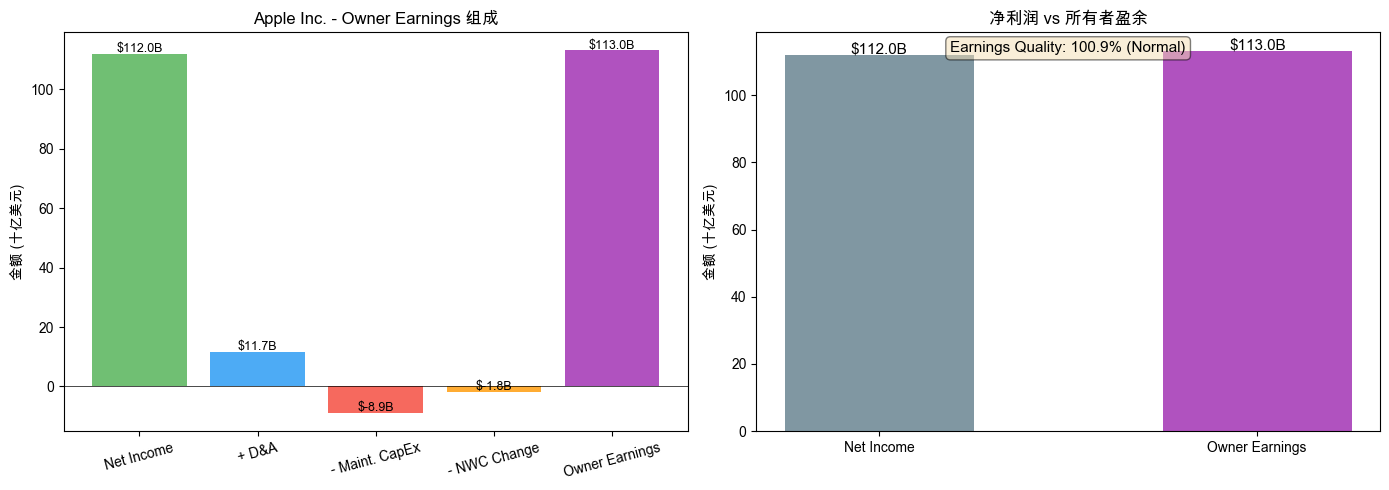

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

d = result.details
c = result.components

# 左图：Owner Earnings 组成瀑布图
ax1 = axes[0]
labels = ['Net Income', '+ D&A', '- Maint. CapEx', '- NWC Change', 'Owner Earnings']
values = [
    c['net_income'] / 1e9,
    c['depreciation'] / 1e9,
    -c['maintenance_capex'] / 1e9,
    -c['nwc_change'] / 1e9,
    d['owner_earnings'] / 1e9,
]
colors = ['#4CAF50', '#2196F3', '#F44336', '#FF9800', '#9C27B0']

bars = ax1.bar(labels, values, color=colors, alpha=0.8)
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.set_ylabel('金额 (十亿美元)')
ax1.set_title(f'{stock.name} - Owner Earnings 组成')
ax1.tick_params(axis='x', rotation=15)

for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'${val:.1f}B', ha='center', fontsize=9)

# 右图：Net Income vs Owner Earnings 对比 + 盈利质量
ax2 = axes[1]
metrics = ['Net Income', 'Owner Earnings']
amounts = [c['net_income']/1e9, d['owner_earnings']/1e9]
bars2 = ax2.bar(metrics, amounts, color=['#607D8B', '#9C27B0'], alpha=0.8, width=0.5)
ax2.set_ylabel('金额 (十亿美元)')
ax2.set_title(f'净利润 vs 所有者盈余')

for bar, val in zip(bars2, amounts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:.1f}B', ha='center', fontsize=11, fontweight='bold')

# 添加盈利质量标注
eq = d['earnings_quality']
eq_label = "Cash-rich" if eq > 1.2 else ("Accrual-heavy" if eq < 0.8 else "Normal")
ax2.text(0.5, 0.95, f'Earnings Quality: {eq:.1%} ({eq_label})', 
         transform=ax2.transAxes, ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 7. 多公司盈利质量对比

对比不同公司的 Owner Earnings 和盈利质量。

In [7]:
# 对比多公司
tickers = ["AAPL", "MSFT", "GOOGL", "JPM", "BRK-B"]

rows = []
for t in tickers:
    try:
        s = Stock.from_api(t)
        r = engine.run_single(s, "owner_earnings")
        
        oe_val = r.details.get('owner_earnings', 0) if r.details else 0
        eq = r.details.get('earnings_quality', 0) if r.details else 0
        oe_ps = r.details.get('owner_earnings_per_share', 0) if r.details else 0
        
        row = {
            'Ticker': t,
            'Name': s.name[:20],
            'Price': s.current_price,
            'NI($B)': s.net_income / 1e9,
            'OE($B)': oe_val / 1e9 if oe_val else None,
            'OE/Share': oe_ps,
            'EQ': eq,
            'OE Fair Value': r.fair_value if r.fair_value and r.fair_value > 0 else None,
            'Premium%': r.premium_discount if r.fair_value and r.fair_value > 0 else None,
            'Confidence': r.confidence,
        }
        rows.append(row)
        print(f"  {t} - done")
    except Exception as e:
        print(f"  {t} - failed: {e}")

df = pd.DataFrame(rows)

def fmt(x):
    if x is None:
        return 'N/A'
    if isinstance(x, float):
        return f'{x:.2f}'
    return str(x)

print("\n" + "=" * 90)
print("Owner Earnings 多公司对比")
print("=" * 90)
print(df.to_string(index=False, float_format=fmt))

  AAPL - done
  MSFT - done
  GOOGL - done
  JPM - done
  BRK-B - done

Owner Earnings 多公司对比
Ticker                 Name  Price  NI($B)  OE($B)  OE/Share   EQ  OE Fair Value  Premium% Confidence
  AAPL           Apple Inc. 246.63  112.01  113.04      7.70 1.01          96.25    -61.00     Medium
  MSFT Microsoft Corporatio 358.96  101.83   85.81     11.56 0.84         144.45    -59.80     Medium
 GOOGL        Alphabet Inc. 273.50  132.17   78.96     13.56 0.60         169.54    -38.00        Low
   JPM JPMorgan Chase & Co. 283.77   57.05   51.32     19.03 0.90         225.17    -20.60     Medium
 BRK-B Berkshire Hathaway I 474.66   66.97   61.69     44.36 0.92         427.62     -9.90     Medium


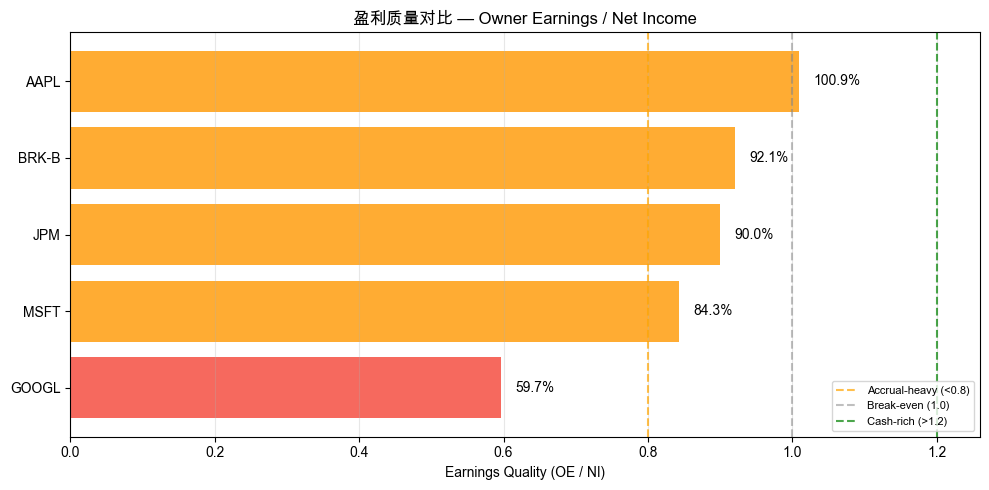

In [8]:
# 可视化：Earnings Quality 对比
fig, ax = plt.subplots(figsize=(10, 5))

valid_eq = df.dropna(subset=['EQ']).sort_values('EQ', ascending=True)

colors = ['#F44336' if x < 0.8 else ('#4CAF50' if x > 1.2 else '#FF9800') for x in valid_eq['EQ']]
bars = ax.barh(valid_eq['Ticker'], valid_eq['EQ'], color=colors, alpha=0.8)

# 参考线
ax.axvline(x=0.8, color='orange', linestyle='--', alpha=0.7, label='Accrual-heavy (<0.8)')
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Break-even (1.0)')
ax.axvline(x=1.2, color='green', linestyle='--', alpha=0.7, label='Cash-rich (>1.2)')

for bar, val in zip(bars, valid_eq['EQ']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center')

ax.set_xlabel('Earnings Quality (OE / NI)')
ax.set_title('盈利质量对比 — Owner Earnings / Net Income')
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 维持性 CapEx 敏感度分析

Owner Earnings 的关键假设是**维持性 CapEx 占总 CapEx 的比例**。让我们看看不同假设如何影响结果。

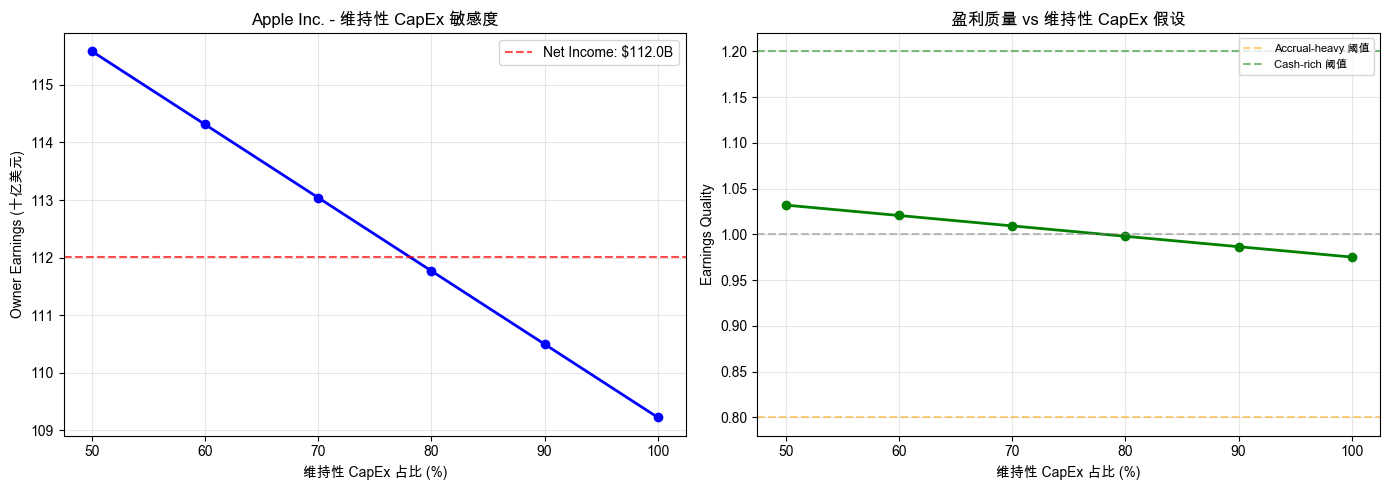


关键洞察：
   当维持性 CapEx 占比从 50% 增加到 100%：
   Owner Earnings 从 $115.6B 降至 $109.2B
   这说明准确区分维持性 vs 增长性 CapEx 非常重要


In [9]:
# 敏感度分析：维持性 CapEx 占比从 50% 到 100%
maint_pcts = np.arange(0.5, 1.05, 0.1)
oe_values = []
eq_values = []

ni = stock.net_income
dep = stock.depreciation if stock.depreciation > 0 else stock.revenue * 0.05
capex = abs(stock.capex)
nwc_c = abs(stock.net_working_capital) * 0.1 if stock.net_working_capital != 0 else stock.revenue * 0.01

for pct in maint_pcts:
    mc = capex * pct
    oe = ni + dep - mc - nwc_c
    oe_values.append(oe / 1e9)
    eq_values.append(oe / ni if ni != 0 else 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：Owner Earnings vs 维持性 CapEx 占比
ax1.plot(maint_pcts * 100, oe_values, 'bo-', linewidth=2)
ax1.axhline(y=ni/1e9, color='red', linestyle='--', alpha=0.7, label=f'Net Income: ${ni/1e9:.1f}B')
ax1.set_xlabel('维持性 CapEx 占比 (%)')
ax1.set_ylabel('Owner Earnings (十亿美元)')
ax1.set_title(f'{stock.name} - 维持性 CapEx 敏感度')
ax1.legend()
ax1.grid(alpha=0.3)

# 右图：Earnings Quality vs 维持性 CapEx 占比
ax2.plot(maint_pcts * 100, eq_values, 'go-', linewidth=2)
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=0.8, color='orange', linestyle='--', alpha=0.5, label='Accrual-heavy 阈值')
ax2.axhline(y=1.2, color='green', linestyle='--', alpha=0.5, label='Cash-rich 阈值')
ax2.set_xlabel('维持性 CapEx 占比 (%)')
ax2.set_ylabel('Earnings Quality')
ax2.set_title('盈利质量 vs 维持性 CapEx 假设')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n关键洞察：")
print(f"   当维持性 CapEx 占比从 50% 增加到 100%：")
print(f"   Owner Earnings 从 ${max(oe_values):.1f}B 降至 ${min(oe_values):.1f}B")
print(f"   这说明准确区分维持性 vs 增长性 CapEx 非常重要")

## 9. 零增长 vs 含增长估值

valueinvest 库的 Owner Earnings 估值使用两种模型取平均：
- **零增长模型**：V = OE_per_share / WACC
- **含增长模型**：V = OE_per_share * (1+g) / (WACC - g)

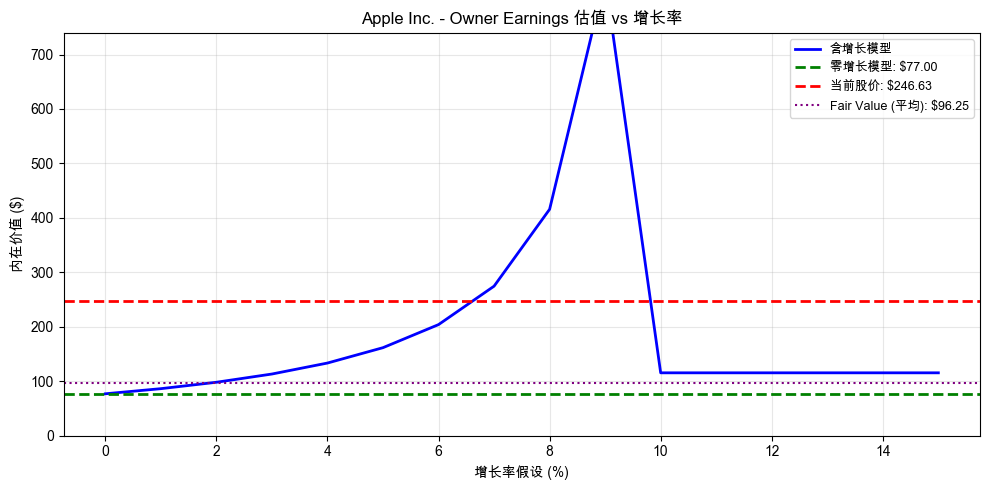


估值模型说明：
   零增长模型假设公司不再增长，是最保守的估计
   含增长模型考虑未来增长率，但增长率越高结果越不确定
   valueinvest 使用两者平均值作为最终 Fair Value


In [10]:
# 估值模型对比
wacc = stock.cost_of_capital / 100
oe_ps = result.details['owner_earnings_per_share'] if result.details else 0

growth_rates = np.arange(0, 15.1, 1)
values = []
for g in growth_rates:
    g_pct = g / 100
    if wacc > g_pct:
        v = oe_ps * (1 + g_pct) / (wacc - g_pct)
    else:
        v = oe_ps / wacc * 1.5
    values.append(v)

v_zero = oe_ps / wacc

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(growth_rates, values, 'b-', linewidth=2, label='含增长模型')
ax.axhline(y=v_zero, color='green', linestyle='--', linewidth=2, label=f'零增长模型: ${v_zero:.2f}')
ax.axhline(y=stock.current_price, color='red', linestyle='--', linewidth=2, label=f'当前股价: ${stock.current_price:.2f}')

# 标记最终 fair value
if result.fair_value and result.fair_value > 0:
    ax.axhline(y=result.fair_value, color='purple', linestyle=':', linewidth=1.5, 
               label=f'Fair Value (平均): ${result.fair_value:.2f}')

ax.set_xlabel('增长率假设 (%)')
ax.set_ylabel('内在价值 ($)')
ax.set_title(f'{stock.name} - Owner Earnings 估值 vs 增长率')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0, min(max(values) * 1.1, stock.current_price * 3))

plt.tight_layout()
plt.show()

print(f"\n估值模型说明：")
print(f"   零增长模型假设公司不再增长，是最保守的估计")
print(f"   含增长模型考虑未来增长率，但增长率越高结果越不确定")
print(f"   valueinvest 使用两者平均值作为最终 Fair Value")

## 10. Owner Earnings 的局限性和最佳实践

### 局限性

1. **维持性 CapEx 难以精确估算**
   - 公司财报通常只报告总 CapEx，不区分维持性和增长性
   - valueinvest 默认假设 70% 为维持性（保守估计）

2. **营运资金变动估计简化**
   - 需要历史数据才能准确计算 ΔNWC
   - 当前实现使用 10% 的 NWC 作为代理

3. **不适用于高增长公司**
   - 大量增长性 CapEx 会被误算为维持性
   - 营运资金变动剧烈，估计不稳定

4. **增长率的敏感性**
   - 含增长模型对增长率高度敏感
   - WACC 接近增长率时，估值趋向无穷大

### 最佳实践

1. **优先用于成熟公司**
   - 现金流稳定、CapEx 可预测
   - 如消费品、公用事业、金融

2. **作为盈利质量过滤器**
   - Earnings Quality < 0.8 是红旗信号
   - 配合 Piotroski F-Score 使用

3. **保守估计维持性 CapEx**
   - 宁可高估维持性 CapEx（降低 Owner Earnings）
   - 巴菲特倾向于使用总 CapEx 代替维持性 CapEx

4. **结合其他估值方法**
   - Owner Earnings + DCF（交叉验证）
   - Owner Earnings + FCF 分析

In [11]:
# 综合分析：与其他方法对比
print(f"综合估值分析 - {stock.name}")
print("=" * 60)

results_all = engine.run_all(stock)
valid_results = [(r.method, r.fair_value, r.premium_discount, r.confidence) 
                 for r in results_all if r.fair_value and r.fair_value > 0]

if valid_results:
    df_all = pd.DataFrame(valid_results, 
                          columns=['方法', '内在价值', '溢价/折价%', '置信度'])
    
    def fmt_r(x):
        if isinstance(x, str):
            return x
        if isinstance(x, float):
            return f'{x:.2f}'
        return str(x)
    
    print(df_all.to_string(index=False, float_format=fmt_r))
    
    avg = np.mean([r[1] for r in valid_results])
    print(f"\n平均估值：${avg:.2f}")
    print(f"当前股价：${stock.current_price:.2f}")
    print(f"\nOwner Earnings 在综合分析中的角色：")
    print("  1. 提供盈利质量视角（其他方法可能忽略）")
    print("  2. 作为'现金现实'的校准基准")
    print("  3. 帮助识别净利润虚高的公司")

综合估值分析 - Apple Inc.
                 方法   内在价值  溢价/折价%    置信度
     Graham Formula 262.02    6.20   High
      DCF (10-Year) 103.61  -58.00   High
        Reverse DCF 246.63    0.00   High
  EPV (Zero Growth)  74.91  -69.60    Low
DDM (Gordon Growth)  37.51  -84.80   High
      Two-Stage DDM  14.90  -94.00 Medium
          PEG Ratio 124.19  -49.60   High
               GARP 167.50  -32.10    Low
         Rule of 40 246.63    0.00   High
      P/B Valuation 112.48  -54.40   High
    Residual Income 736.69  198.70 Medium
      Magic Formula  86.35  -65.00 Medium
     Owner Earnings  96.25  -61.00 Medium
          EV/EBITDA 125.87  -49.00   High
     Altman Z-Score 246.63    0.00   High
       SBC Analysis 246.63    0.00   High
Value Trap Detector 246.63    0.00   High
  Piotroski F-Score 246.63    0.00   High
        PE Relative 232.40   -5.80    Low
        PB Relative 274.98   11.50    Low
    Beneish M-Score 246.63    0.00    Low

平均估值：$198.86
当前股价：$246.63

Owner Earnings 在综合分析中的角色：
  

## 11. 总结

### 关键要点

1. **Owner Earnings = Net Income + D&A - Maintenance CapEx - ΔNWC**
   - 衡量公司真正能分配给股东的现金
   - 比净利润更接近经济现实

2. **盈利质量是关键指标**
   - OE/NI > 1.2 = Cash-rich（优秀）
   - OE/NI < 0.8 = Accrual-heavy（警惕）

3. **维持性 CapEx 的估计是最大的不确定性**
   - 保守估计比精确估计更重要
   - 做敏感度分析检验结果稳健性

4. **适用场景**
   - 成熟、现金流稳定的公司
   - 作为盈利质量过滤器和估值交叉验证

---

**参考资料**：
- [ValueInvest GitHub](https://github.com/wangzhe3224/valueinvest)
- Berkshire Hathaway 1986 Annual Report - Warren Buffett
- 《巴菲特致股东的信》- Warren Buffett